## Running SOLFD
This notebook walks through all the key steps involved in running the SOLFD workflow.

### The imports
- **ProcessingSkyViewFactorAlgorithm**: Main algorithm for SVF creation; includes 2.5D and 3D versions.
- **SOLWEIGalgorithm**: Core SOLWEIG model; supports both 2.5D and 3D variants.
- **DEMs.Buildings**: Manages building polygons, including ID handling, removal, and insertion.
- **DEMs.DEMS**: Handles creation and updating of DTM and DSM layers.
- **DEMs.CHM**: Manages CHM (Canopy Height Model) creation and updates.
- **LandCover**: Generates and updates land cover maps from BGT or TOP10NL sources.
- **Surface_input**: Inserts new materials into land cover using triangulated mesh `.obj` surfaces.
- **Building3d_input**: Inserts 3D building designs from triangulated `.obj` meshes into SOLFD.
- **TrmtOutput**: Post-processes output from the SOLWEIG model.
- **src.util.misc.saveraster**: Utility function for saving raster outputs.

In [1]:
from src.preprocessor.skyviewfactor_algorithm_qgisless import ProcessingSkyViewFactorAlgorithm as SVF
from src.processor.solweig_algorithm_qgisless_cupy import SOLWEIGAlgorithm as Solweig
from src.j_dataprep.DEMs import Buildings, DEMS, CHM
from src.j_dataprep.landcover import LandCover
from src.j_dataprep.user_input import Surface_input, Building3d_input
from src.j_dataprep.wall_preprocess import WallData
from src.j_output.user_output import TmrtOutput
from src.util.misc import saveraster
from osgeo import gdal

### Functions to show the raster outputs of the steps with

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape
import rasterio
import numpy as np
import pandas as pd

def show_raster_array(array, raster_type='generic', title='Raster', vmin=None, vmax=None):
    cmap_dict = {
        'height': 'viridis',
        'temperature': 'turbo',
        'generic': 'gray',
        'diverging': 'bwr'
    }

    cmap = cmap_dict.get(raster_type, 'gray')

    plt.figure(figsize=(7, 7))
    img = plt.imshow(array, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(img, label='Pixel Value')
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.grid(False)
    plt.show()

def plot_geojson(geojson_list, crs="EPSG:28992", color='blue', edgecolor='black', labels=False):
    geoms = [shape(g['geometry']) for g in geojson_list]
    polygon_ids = [g.get('polygon_id', None) for g in geojson_list]

    gdf = gpd.GeoDataFrame({'polygon_id': polygon_ids, 'geometry': geoms}, crs=crs)

    ax = gdf.plot(color=color, edgecolor=edgecolor, figsize=(7, 7))

    if labels:
        for _, row in gdf.iterrows():
            centroid = row.geometry.centroid
            label = str(row['polygon_id']) if row['polygon_id'] is not None else ''
            ax.text(centroid.x, centroid.y, label, fontsize=8, ha='center', va='center', color='white')

    plt.title("Polygon Geometries")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

def save_multilayer_dsm(dsm_array, crs, transform, filename):
    if isinstance(dsm_array, list):
        dsm_array = np.array(dsm_array)

    layers, height, width = dsm_array.shape

    with rasterio.open(
        filename,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=layers,
        dtype=dsm_array.dtype,
        crs=crs,
        transform=transform,
    ) as dst:
        for i in range(layers):
            dst.write(dsm_array[i, :, :], i + 1)

def plot_tmrt_distribution_over_time(tmrt_arrays_by_time, pixel_size):
    '''
    Plot how Tmrt bin distributions evolve over time (e.g., from 800 to 2000).

    Parameters:
        tmrt_arrays_by_time (dict): Dictionary with time keys (e.g., '0800', '1200') and Tmrt arrays as values.
        pixel_size (float): Pixel resolution in meters (used to compute area).
    '''

    # Sort time keys numerically but preserve their original string format (e.g., '0800')
    sorted_times = sorted(tmrt_arrays_by_time.keys(), key=lambda x: int(x))

    # Use the first available array to extract consistent bin labels
    first_array = tmrt_arrays_by_time[sorted_times[0]]
    first_bins = data.calculate_stats_and_bins(first_array, pixel_size=pixel_size, isTmrt=True)['bins']

    bin_labels = []
    for b in first_bins:
        r_min_raw = b['range'][0]
        r_max = b['range'][1]

        if np.isfinite(r_min_raw):
            r_min = round(float(r_min_raw))
            r_min_str = str(r_min)
        else:
            r_min_str = '–∞'

        if np.isfinite(r_max):
            label = f"{r_min_str}–{int(r_max)}°C"
        else:
            label = f"{r_min_str}–∞°C"

        bin_labels.append(label)

    # Initialize DataFrame to hold bin percentages for each time step
    df = pd.DataFrame(
        data=0.0,
        index=[int(t) for t in sorted_times],
        columns=bin_labels,
        dtype=float
    )

    for t in sorted_times:
        array = tmrt_arrays_by_time[t]
        stats = data.calculate_stats_and_bins(array, pixel_size=pixel_size, isTmrt=True)
        bins = stats['bins']

        for b, label in zip(bins, bin_labels):
            df.loc[int(t), label] = float(b['percentage'])

    # Sort the DataFrame by time
    df = df.sort_index()

    # Plot
    df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='coolwarm', edgecolor='black')

    plt.title('Tmrt Bin Distribution Over Time')
    plt.xlabel('Time')
    plt.ylabel('Area (%)')
    plt.xticks(rotation=45)
    plt.legend(title='Tmrt Range', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## **Start with retrieving context**

### Using the `Buildings` Class

The `Buildings` class allows retrieval and manipulation of 3D BAG buildings using a bounding box in **Amersfoort RD New** coordinates.

#### Core Functionality

- **Building Retrieval**:
  - Only a bounding box is required to retrieve buildings.
  - The default dataset is **LOD13** from the 3DBAG.
  - Output is saved as a GPKG file with customizable:
    - Output folder
    - File name
    - Layer name
    - 3DBAG source layer

#### Key Methods

- **`remove_buildings(parcel_ids)`**
  Marks one or more real buildings as removed by adding their parcel IDs to the internal removed list.

- **`retrieve_buildings(parcel_ids)`**
  Undoes a previous removal by removing specified parcel IDs from the removed list.

- **`insert_user_buildings(heights, footprints=None)`**
  Inserts user-defined buildings.
  - Assigns unique parcel IDs.
  - If `footprints` are provided, they are matched to the highest buildings first.

- **`remove_user_buildings(parcel_ids)`**
  Marks user-inserted buildings as removed by adding their parcel IDs to the internal removed list.

- **`retrieve_user_buildings(parcel_ids)`**
  Undoes the removal of user-defined buildings by removing their parcel IDs from the removed list.



In [3]:
# All input that is officially needed: bbox for area
bbox= (123450,484200, 123700,484450)
buildings = Buildings(bbox)

loaded


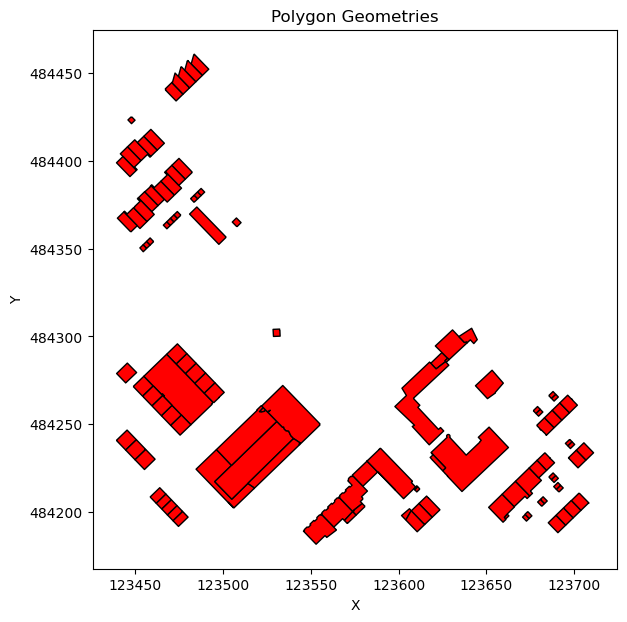

In [4]:
plot_geojson(buildings.building_geometries, color='red')

### Using the `DEM` Class

To create the DSM (Digital Surface Model) and DTM (Digital Terrain Model), a bounding box is required along with the `.building_geometries` from the `Buildings` class.

#### Configuration Options

- Customizable resolution (default: 0.5 m)
- Option to include `'overbruggingsdeel'` elements in the DSM
- Selectable resampling method (only relevant if resolution < 0.5 m)
- Custom output directory for DSM/DTM files

#### Key Methods

- **`update_dsm`**
  Updates the DSM with new user building heights.
  Supports both 2D and 3D DSM array formats.

- **`remove_buildings`**
  Removes specified buildings from the DSM by replacing their areas with DTM values.

- **`update_building_height`**
  Raises the height of specified user buildings in the DSM by the given amount.


In [5]:
DSM = DEMS(bbox, buildings.building_geometries)

4
(500, 500)
4
(500, 500)
File written to 'output/final_dtm.tif'
File written to 'output/final_dsm.tif'


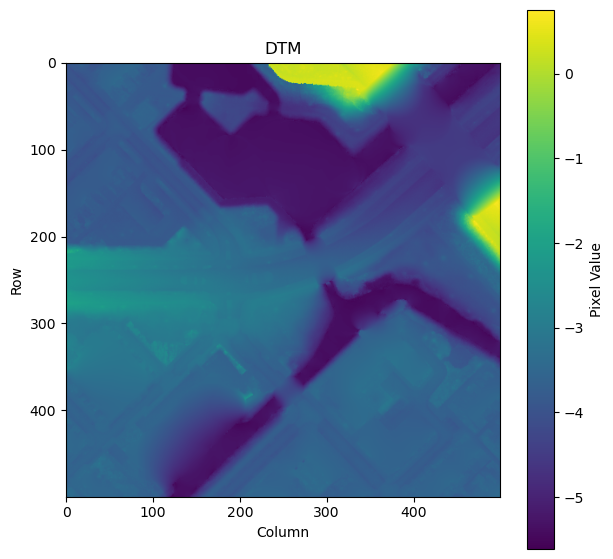

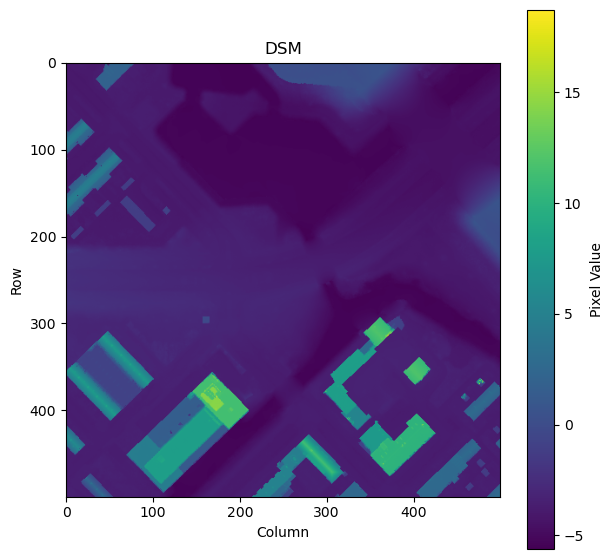

In [6]:
show_raster_array(DSM.dtm, raster_type='height', title='DTM')
show_raster_array(DSM.dsm, raster_type='height', title='DSM')

### Using the `CHM` Class

The `CHM` class creates and manages **Canopy Height Models (CHMs)** from LiDAR data.

It supports downloading and merging LAS/LAZ tiles, filtering vegetation points by classification and NDVI, rasterizing vegetation using interpolation, applying smoothing filters, and generating the final CHM and trunk zone raster outputs.

#### Requirements

- A bounding box (in RD New)
- DTM and DSM rasters
- Desired `trunk_height` (percentage of tree height used for trunk zone array)

#### Configuration Options

- Output folder (for CHM and LAS files)
- CHM raster resolution
- Merged output point cloud filename

#### Key Methods

- **`remove_trees`**
  Removes a tree or group of trees from both the CHM and trunk arrays using the given polygon ID(s).

- **`insert_tree`**
  Inserts a parametric tree model into the CHM and trunk height arrays at a specified location.

- **`insert_random_tree`**
  Inserts a tree with randomized dimensions at a given position.
  - Height, crown radius, trunk height, and canopy base height are randomly selected from given ranges.
  - Ensures the canopy height exceeds a minimum threshold.

- **`insert_type_tree`**
  Inserts a tree of a specific type and age using parameters from a JSON database.
  - Computes trunk height and crown radius based on growth data.
  - Canopy shape is fixed per species.


In [7]:
chm = CHM(bbox, DSM.dtm, DSM.dsm, trunk_height=25)

Tiles covering the area: ['25GN1_14']
Saved vegetation points to output\veg_points.las
(500, 500)
File written to 'output\CHM.TIF'


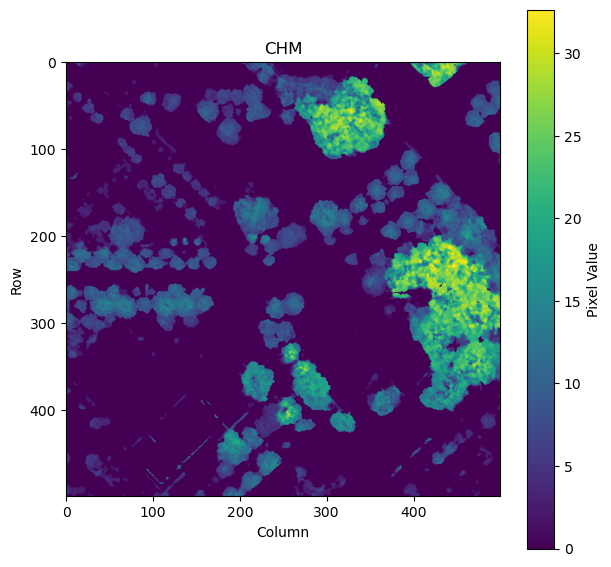

In [8]:
show_raster_array(chm.chm, raster_type='height', title='CHM')

### Using the `LandCover` Class

The `LandCover` class processes and rasterizes land cover data from the **PDOK Top10NL** or **BGT** API, along with building geometries and a DTM raster. It produces a land cover classification raster.

#### Requirements

- A bounding box (in RD New)
- Building geometries from the `Buildings` class

#### Configuration Options

- **Data source**: `'bgt'` (default) or `'top10nl'` (less detailed)
- **No-data fill class**: Default is `0` (cobblestone)
- **Roads-on-top**: If `True`, the upper road is used in case of roads crossing at different heights

#### Key Methods

- **`save_raster`**
  Saves the current raster array to a GeoTIFF file.
  You can optionally change the nodata value in the output.

- **`update_build_landcover`**
  Updates the raster by rasterizing building geometries using land cover code `2`.

- **`update_landcover`**
  Updates the raster for cells where `input_array > -1` with the specified `land_type_code`.

- **`export_context`**
  Exports the current land cover and building context to a `.dxf` or other supported format.



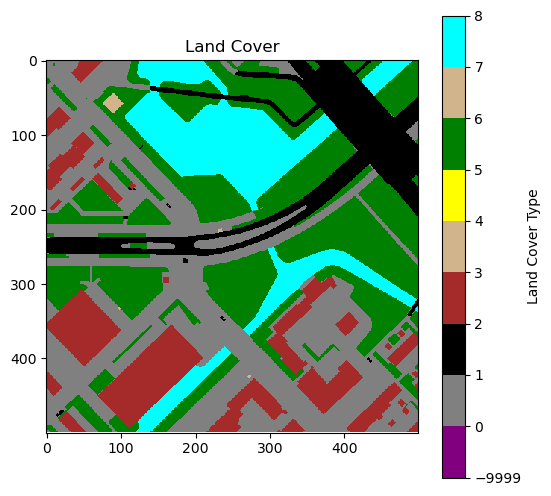

In [9]:
landcover = LandCover(bbox, main_roadtype=0, resolution=0.5, building_data=buildings.building_geometries, dataset_path="output/final_dtm.tif")

In [10]:
landcover.export_context('output/context.dxf')

Exported data to output/context.dxf


### The Exported Context and the Made Designs

<img src="figs/context_inrhino.png" alt="Context in Rhino" width="50%"/>

**Figure 1**: Example of the exported context from the `LandCover` class visualized in CAD software.
The drawing contains layered and color-coded linework per land cover type.

<img src="figs/input.png" alt="Design Input Example" width="50%"/>

**Figure 2**: A sample design with added elements, including a building and water surface, overlaid on the exported context.


## Now update the context with design elements

#### First: remove a building

In [11]:
buildings.remove_buildings("NL.IMBAG.Pand.0363100012091340")
DSM.remove_buildings(buildings.removed_buildings, buildings.removed_user_buildings, buildings.building_geometries, buildings.user_buildings)

Parcel IDs being checked (to_remove): ['NL.IMBAG.Pand.0363100012098799', 'NL.IMBAG.Pand.0363100012072924', 'NL.IMBAG.Pand.0363100012090847', 'NL.IMBAG.Pand.0363100012134409', 'NL.IMBAG.Pand.0363100012126302', 'NL.IMBAG.Pand.0363100012126302', 'NL.IMBAG.Pand.0363100012188387', 'NL.IMBAG.Pand.0363100012188384', 'NL.IMBAG.Pand.0363100012110947', 'NL.IMBAG.Pand.0363100012102489', 'NL.IMBAG.Pand.0363100012188391', 'NL.IMBAG.Pand.0363100012100191', 'NL.IMBAG.Pand.0363100012188388', 'NL.IMBAG.Pand.0363100012071193', 'NL.IMBAG.Pand.0363100012071193', 'NL.IMBAG.Pand.0363100012089889', 'NL.IMBAG.Pand.0363100012120729', 'NL.IMBAG.Pand.0363100012150498', 'NL.IMBAG.Pand.0363100012101612', 'NL.IMBAG.Pand.0363100012101612', 'NL.IMBAG.Pand.0363100012188389', 'NL.IMBAG.Pand.0363100012123468', 'NL.IMBAG.Pand.0363100012128881', 'NL.IMBAG.Pand.0363100012147438', 'NL.IMBAG.Pand.0363100012075042', 'NL.IMBAG.Pand.0363100012142057', 'NL.IMBAG.Pand.0363100012097171', 'NL.IMBAG.Pand.0363100012138305', 'NL.IMBAG

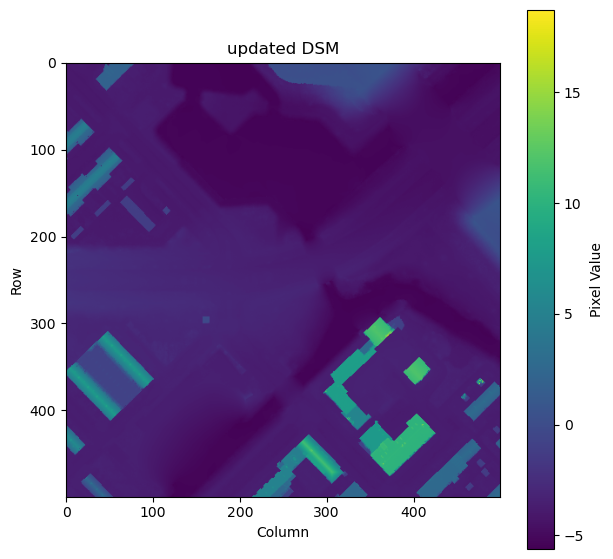

In [12]:
show_raster_array(DSM.dsm, raster_type='height', title='updated DSM')

## Inserting a new design

#### Inserting a New Building

To insert new buildings into the design, use the `Building3d_input` class.

This class handles 3D building input rasterization and generates DSM layers that include optional vertical gaps (voids).

#### Class Attributes

- **`cols`** *(int)*: Number of columns in the raster grid
- **`rows`** *(int)*: Number of rows in the raster grid
- **`res`** *(float)*: Spatial resolution of each cell in the raster grid

#### Key Method

- **`rasterize_3dbuilding(obj_path, num_gaps)`**
  Rasterizes a 3D building from an `.obj` file into a DSM format.
  - `obj_path`: Path to the input OBJ file
  - `num_gaps`: Number of vertical gaps (voids) to include in the building
    - Set to `0` for a fully filled building without internal voids.
    - Gaps are included from the ground up in the output DSM

#### NOTE:
> - Meshes do not need to be closed, but ensure that no geometries intersect with each other.
> - Make sure the mesh is fully triangulated (for example, use the `TriangulateMesh` command in Rhino).
> - Use the `.dxf` export from the landcover context to correctly position your design. The bottom-left corner should be placed at the origin.
> - Avoid vertical triangles positioned exactly over cell centers. (In the exported `.dxf`, 1 unit corresponds to 1 grid cell length, so do not place geometry exactly at 0.5 units.)



In [13]:
dsms, highest_array, input_arrays = Building3d_input(DSM.dtm.shape[1], DSM.dtm.shape[0], DSM.resolution).rasterize_3dbuilding('output/new_building.obj', num_gaps=1)
buildings.insert_user_buildings(highest_array, DSM.transform, footprint_array=dsms[0])
# print(buildings.user_buildings_higher)
DSM.update_dsm(buildings.user_buildings, user_arrays=dsms, higher_buildings=buildings.user_buildings_higher)


In [14]:
dtm_dataset = gdal.Open('output/final_dtm.tif')

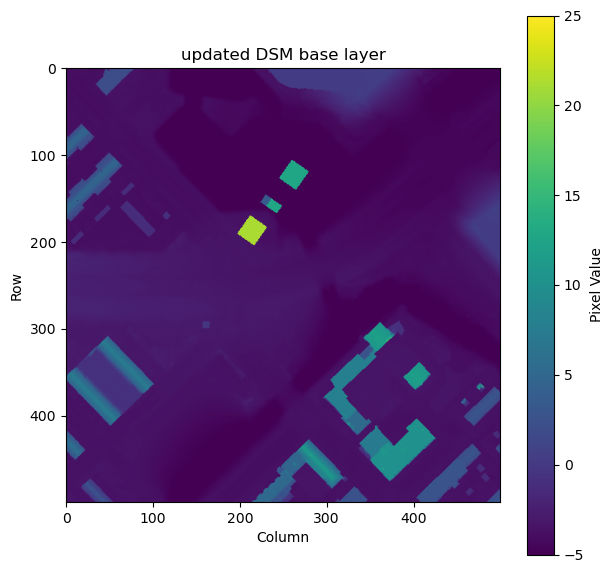

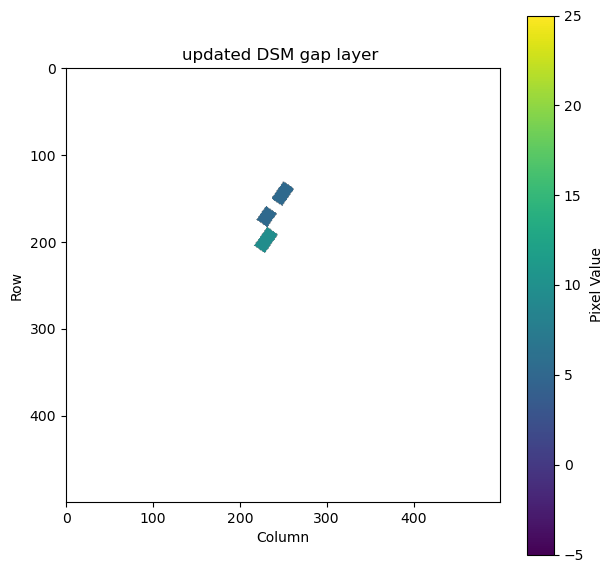

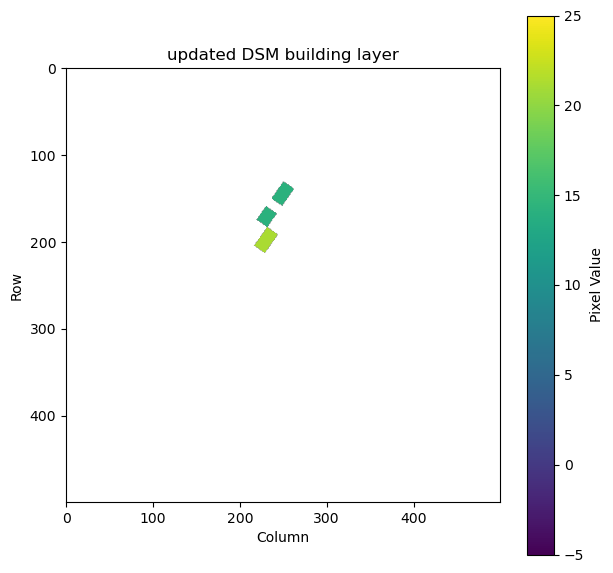

In [15]:
show_raster_array(DSM.dsm[0], raster_type='height', title='updated DSM base layer',vmin=-5, vmax=25)
show_raster_array(DSM.dsm[1], raster_type='height', title='updated DSM gap layer ',vmin=-5, vmax=25)
show_raster_array(DSM.dsm[2], raster_type='height', title='updated DSM building layer',vmin=-5, vmax=25)

## Update Landcover to show new building, also insert new water surface
### New Water Surface Insertion

To insert a new water surface or other custom surface elements, use the `Surface_input` class.

This class processes triangulated mesh surface files (`.obj`) and assigns a land cover type using a category–key combination from the land cover dictionary (`src.databases.landcover_bgt.json`).

#### Key Method

- **`user_input_array(obj_path, type)`**
  Rasterizes the input OBJ file and returns a classified raster and corresponding land cover type code.
  - `obj_path`: Path to the triangulated mesh surface (.obj file)
  - `type`: A list with two elements `[category, key]` used to retrieve the land cover type number



In [16]:
# First update the landcover array with the newly inserted building
landcover.update_build_landcover(buildings.user_buildings)

# Second, update the land coverr array with a new water surface.
input_array, typeno = Surface_input(DSM.dtm.shape[1], DSM.dtm.shape[0], DSM.resolution).user_input_array('output/water.obj', type=['water', 'water'])
landcover.update_landcover(typeno, input_array)

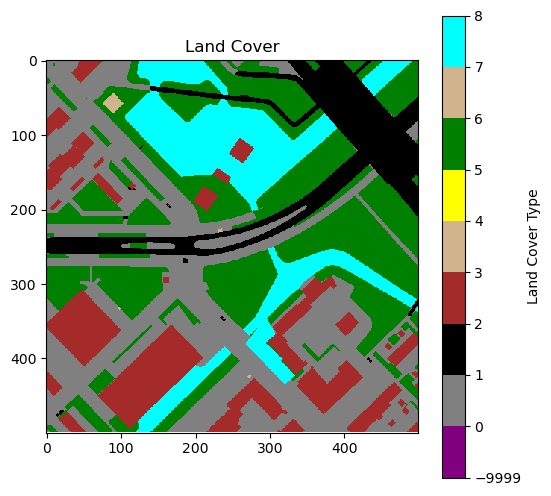

In [17]:
landcover.visualize_raster(landcover.array)

### Removal and insertion of a tree

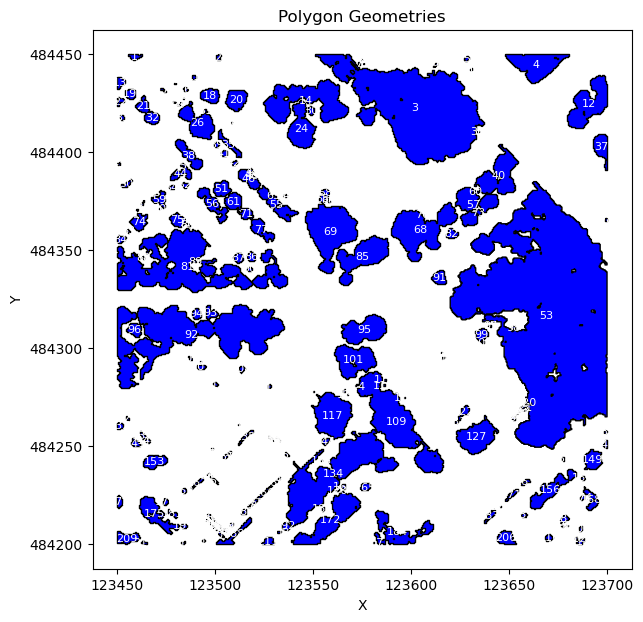

In [18]:
plot_geojson(chm.tree_polygons, labels=True)

In [19]:
chm.remove_trees(53)

File written to 'output/updated_chm.tif'


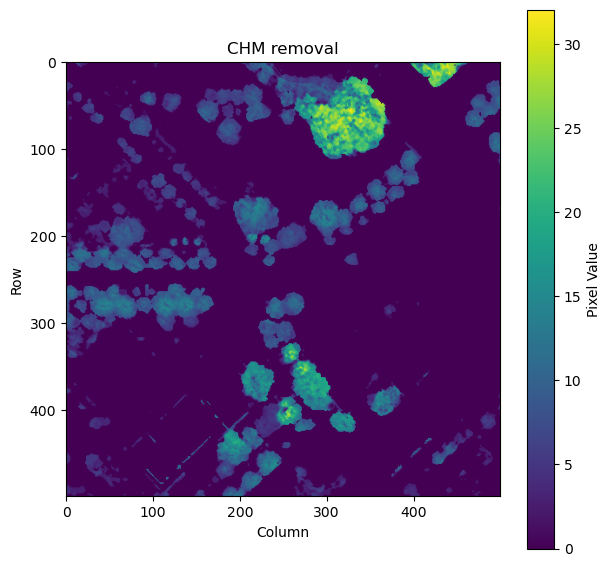

In [20]:
show_raster_array(chm.chm, raster_type='height', title='CHM removal')

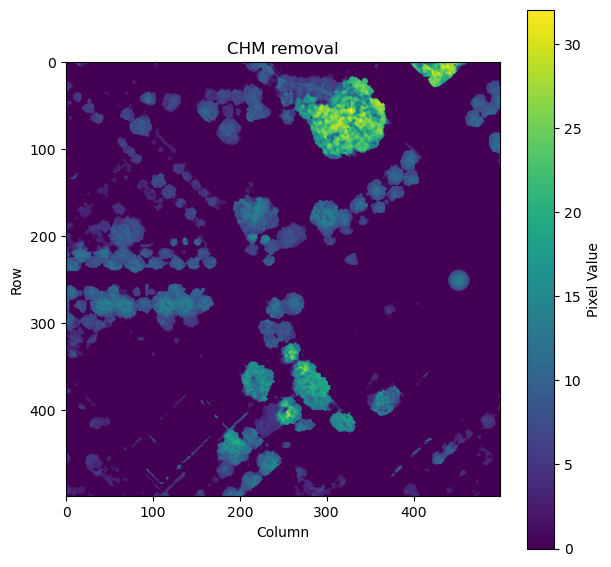

In [21]:
chm.insert_type_tree(age=50, position=(250, 450))
show_raster_array(chm.chm, raster_type='height', title='CHM removal')

## Preparing all rasters for use in SOLWEIG and SVF algorithm.

In [22]:
# Save all rasters (currently SVF and SOLWEIG open tiffs and don't accept already loaded ones)
mult_dsms_path = 'output/run_data/dsms.tif'
dtm_path = 'output/run_data/dtm.tif'
dsm_path = 'output/run_data/dsm.tif'
chm_path = 'output/run_data/chm.tif'
landcover_path = 'output/run_data/landcover.tif'
walla_path = 'output/run_data/wallaspect.tif'
wallh_path = 'output/run_data/wallheight.tif'

In [23]:
save_multilayer_dsm(DSM.dsm, DSM.crs, DSM.transform, mult_dsms_path)
saveraster(dtm_dataset, dsm_path , DSM.dsm[0])
saveraster(dtm_dataset,dtm_path, DSM.dtm)
saveraster(dtm_dataset, chm_path, chm.chm)
saveraster(dtm_dataset,landcover_path, landcover.array)

# create and save wall aspect and height
walls = WallData(DSM.dsm[0], 2)
saveraster(dtm_dataset,walla_path, walls.wall_aspect.get())
saveraster(dtm_dataset,wallh_path, walls.wall_height.get())


## **CREATE SVF**
To compute the Sky View Factor (SVF), use the `processAlgorithm` method.

- For standard (2.5D) SVF computation, run:
  - `processAlgorithm()`

- For full 3D-enabled SVF computation, use:
  - `processAlgorithm_3d()`

In [24]:
SVF(INPUT_DSM=dsm_path, INPUT_CDSM=chm_path, OUTPUT_DIR='output', OUTPUT_FILE='output/svf.tif', INPUT_DTM=dtm_path, INPUT_EXTRAHEIGHT=6, INPUT_MULT_DSMS = mult_dsms_path, INPUT_TDSM=None, USE_VEG=True, TRANS_VEG=15, TSDM_EXIST=False, INPUT_THEIGHT=25.0, ANISO=True).processAlgorithm_3d()

Initiating algorithm
Vegetation scheme activated
Calculating SVF using 153 iterations


C:\thesis\UMEP_thesis\src\util\shadowingfunctions.py:454: RuntimeWarning: divide by zero encountered in scalar divide
  dssin = np.abs(1.0 / sinazimuth)


0
1
1
2
3
3
4
5
5
6
7
7
8
9
9
10
11
11
12
13
13
14
15
15
16
16
17
18
18
19
20
20
21
22
22
23
24
24
25
26
26
27
28
28
29
30
30
31
32
32
33
33
34
35
35
36
37
37
38
39
39
40
41
41
42
43
43
44
45
45
46
47
47
48
49
49
50
50
51
52
52
53
54
54
55
56
56
57
58
58
59
60
60
61
62
62
63
64
64
65
66
66
67
67
68
69
69
70
71
71
72
73
73
74
75
75
76
77
77
78
79
79
80
81
81
82
83
83
84
84
85
86
86
87
88
88
89
90
90
91
92
92
93
94
94
95
96
96
97
98
98
99
100
Sky View Factor: SVF grid(s) successfully generated


{'output': 'output', 'output/svf.tif': 'output/svf.tif'}

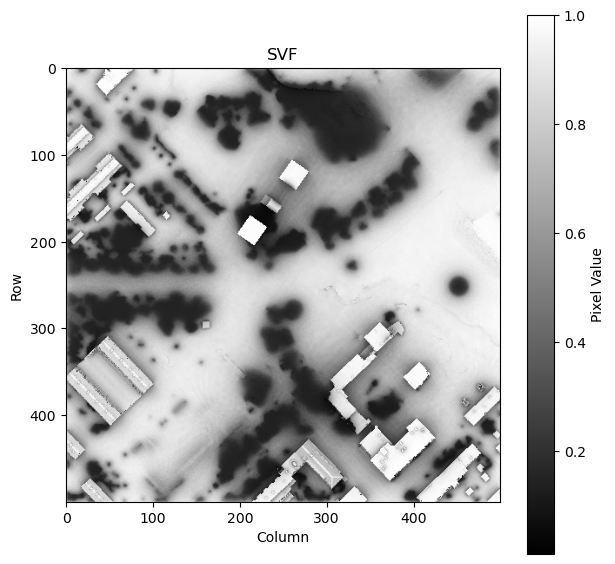

In [25]:
svf_array = gdal.Open('output/svf.tif').ReadAsArray()
show_raster_array(svf_array, raster_type='generic', title='SVF')

### Creating Tmrt

To compute Mean Radiant Temperature (Tmrt), use the `processAlgorithm` method from the `Solweig` processing class.
Make sure to link the desired meteorological input file (`met_data`).

- For standard (2.5D) Tmrt computation, run:
  - `processAlgorithm()`

- For full 3D-enabled Tmrt computation, use:
  - `processAlgorithm_3d()`


DSM raised with 11.6119995m.
Longitude derived from DSM: 4.924206395264258
Latitude derived from DSM: 52.34480783771364
Vegetation scheme activated
Land cover scheme activated
output/svfs/svfveg.tif
Sky View Factor rasters loaded
Meteorological data successfully loaded
Calculating sun positions for each time step
Sky divided into 153 patches
                                     Anisotropic sky for diffuse shortwave radiation (Perez et al., 1993) and longwave radiation (Martin & Berdahl, 1984)
Writing settings for this model run to specified output folder (Filename: RunInfoSOLWEIG_YYYY_DOY_HHMM.txt)
Executing main model
0
4
8
12
16
20
25
29
33
37
41
45
50
54
58
62
66
70
75
79
83
87
91
95
SOLWEIG: Model calculation finished.


{'output/SOLFD': 'output/SOLFD'}

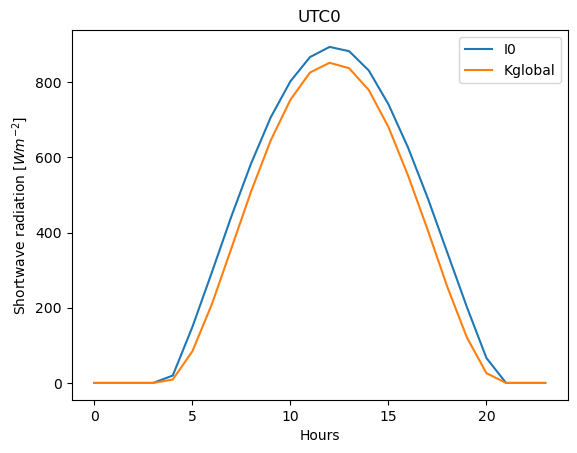

In [26]:
met_data = 'src/j_dataprep/climate/extday_30plus_qgis.txt'

Solweig(INPUT_DSM=dsm_path, INPUT_SVF='output/svfs', INPUT_CDSM=chm_path,  INPUT_HEIGHT=wallh_path, INPUT_ASPECT=walla_path,
                 UTC=0, OUTPUT_DIR='output/SOLFD', INPUT_MET=met_data, INPUT_DTM=dtm_path, INPUT_EXTRAHEIGHT=6, INPUT_MULT_DSMS=mult_dsms_path, INPUT_LC=landcover_path,  INPUT_DEM=None, INPUT_ANISO='output/shadowmats.npz',
                 CONIFER_TREES=False, INPUT_THEIGHT=25, INPUT_TDSM=None, TRANS_VEG=15, LEAF_START=97, LEAF_END=300,
                 USE_LC_BUILD=True).processAlgorithm_3d()

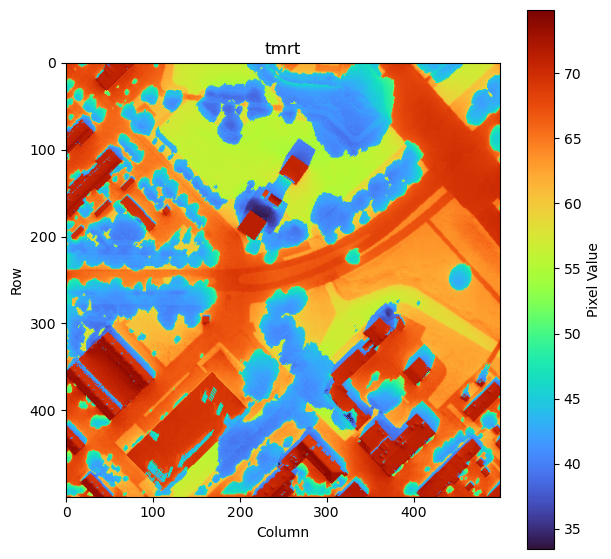

In [27]:
tmrt_array = gdal.Open('output/SOLFD/Tmrt_2023_172_1300D.tif').ReadAsArray()
show_raster_array(tmrt_array, raster_type='temperature', title='tmrt')

In [28]:
data = TmrtOutput('output/SOLFD', landcover.building_mask, landcover.water_mask)

### Statistics examples

In [29]:
data.calculate_stats_and_bins(data.tmrt_arrays_by_time['1200'])

{'mean': np.float32(55.823242),
 'median': np.float32(61.63475),
 'min': np.float32(32.903793),
 'max': np.float32(71.904686),
 'bins': [{'range': (np.float64(-inf), np.float64(15.0)),
   'area_m2': np.float64(0.0),
   'percentage': np.float64(0.0)},
  {'range': (np.float64(15.0), np.float64(20.0)),
   'area_m2': np.float64(0.0),
   'percentage': np.float64(0.0)},
  {'range': (np.float64(20.0), np.float64(25.0)),
   'area_m2': np.float64(0.0),
   'percentage': np.float64(0.0)},
  {'range': (np.float64(25.0), np.float64(30.0)),
   'area_m2': np.float64(0.0),
   'percentage': np.float64(0.0)},
  {'range': (np.float64(30.0), np.float64(35.0)),
   'area_m2': np.float64(74.0),
   'percentage': np.float64(0.16522374979765672)},
  {'range': (np.float64(35.0), np.float64(40.0)),
   'area_m2': np.float64(2926.75),
   'percentage': np.float64(6.534710942166106)},
  {'range': (np.float64(40.0), np.float64(45.0)),
   'area_m2': np.float64(11226.5),
   'percentage': np.float64(25.066005771667477)},

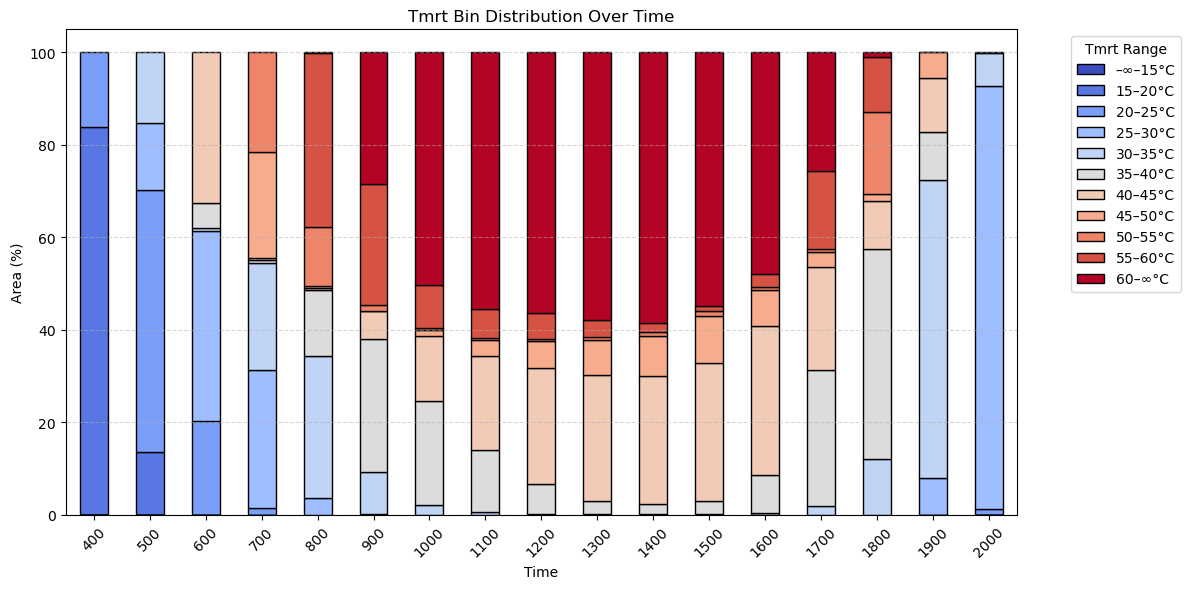

In [30]:
plot_tmrt_distribution_over_time(data.tmrt_arrays_by_time, pixel_size=0.5)

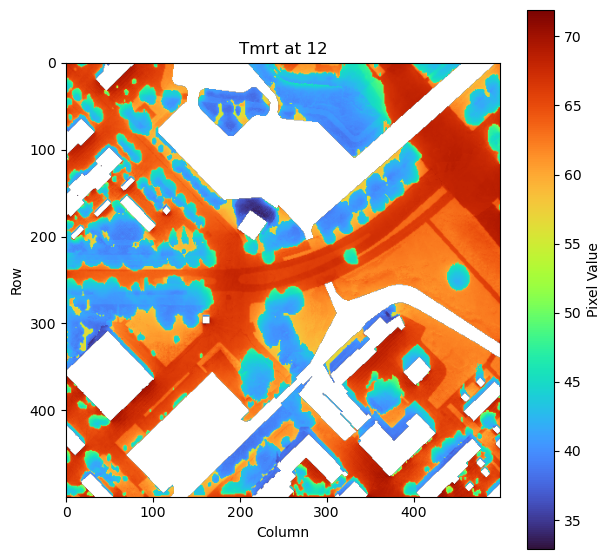

In [31]:
show_raster_array(data.tmrt_arrays_by_time['1200'], 'temperature', 'Tmrt at 12')

#### Pet arrays

In [32]:
data.calc_pet(Ta=28, RH=80, va=2.0)

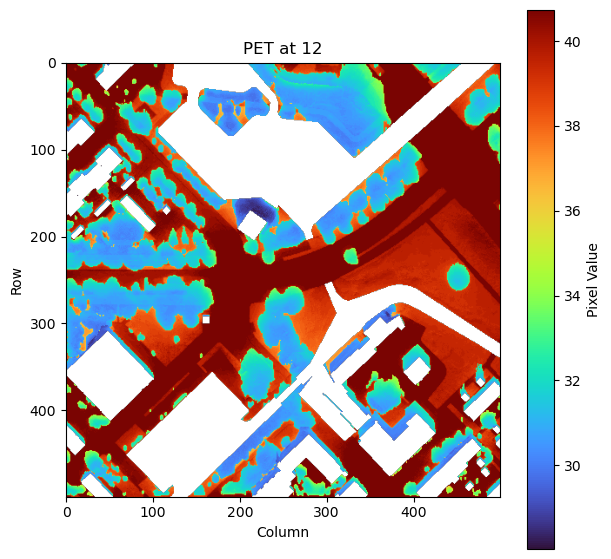

In [33]:
show_raster_array(data.pet_arrays_by_time['1200'], 'temperature', 'PET at 12')

In [34]:
classified_pet = data.classify_pet(data.pet_arrays_by_time['1200'])

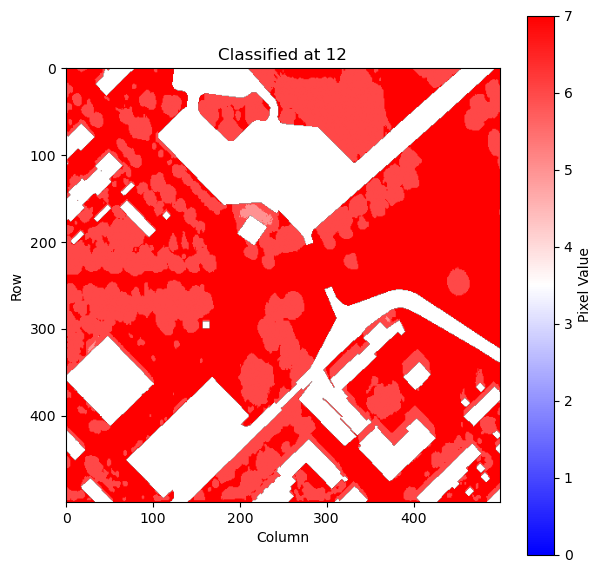

In [35]:
show_raster_array(classified_pet, 'diverging', 'Classified at 12', vmin=0, vmax=7)